# Capstone Project - Regression: House Price Prediction

**Course:** Data Mining & Information Visualization  
**Project type:** Regression (continuous numerical target)  
**Dataset:** [Kaggle House Prices - Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques)  
**Target variable:** `SalePrice` (continuous)

### Workflow covered (per Capstone requirements)
Dataset Selection -> Data Understanding -> Preprocessing -> Feature Selection -> Model Selection -> Training -> Validation -> Testing -> Evaluation -> Visualization -> Interpretation

## 1. Problem Statement & Dataset Selection

**Problem:** Predict the sale price of residential homes from structural, location, and quality attributes.

**Why regression?** `SalePrice` is a continuous numerical target, so this is a supervised regression task (not classification or clustering).

**Data source:** Kaggle House Prices dataset  
- Training set: 1,460 homes with features + `SalePrice`  
- Competition test set: 1,459 homes without labels (used for optional Kaggle-style inference)  

For a complete train -> validate -> test workflow, we hold out a labeled test split from the training data.

## 2. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

## 3. Data Understanding & Exploration

Load the cleaned training data produced from EDA and inspect structure, types, and the target distribution.

In [2]:
train = pd.read_csv("train_cleaned.csv")
kaggle_test = pd.read_csv("test_cleaned.csv")

print("Training shape:", train.shape)
print("Kaggle test shape:", kaggle_test.shape)
print("\nData types:")
print(train.dtypes.value_counts())
train.head()

Training shape: (1460, 81)
Kaggle test shape: (1459, 80)

Data types:
str        43
int64      23
float64    15
Name: count, dtype: int64


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450.0,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600.0,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250.0,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550.0,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260.0,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


count      1460.000000
mean     177331.526370
std       67205.835915
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      340037.500000
Name: SalePrice, dtype: float64


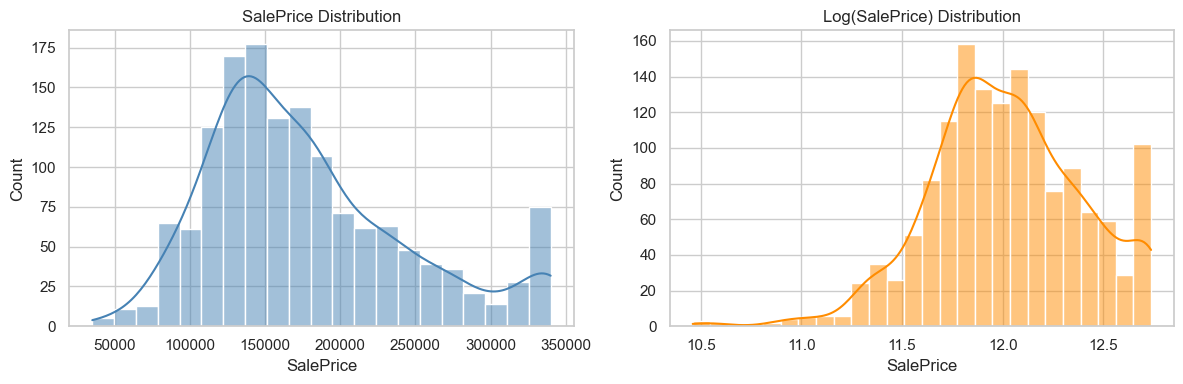

In [3]:
# Target overview
print(train["SalePrice"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train["SalePrice"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("SalePrice Distribution")
sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Log(SalePrice) Distribution")
plt.tight_layout()
plt.show()

In [4]:
# Separate features / target; drop identifier
X_full = train.drop(columns=["SalePrice", "Id"])
y_full = train["SalePrice"]

num_cols = X_full.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_full.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical features: {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")
print(f"Missing values remaining: {X_full.isna().sum().sum()}")

Numerical features: 36
Categorical features: 43
Missing values remaining: 7481


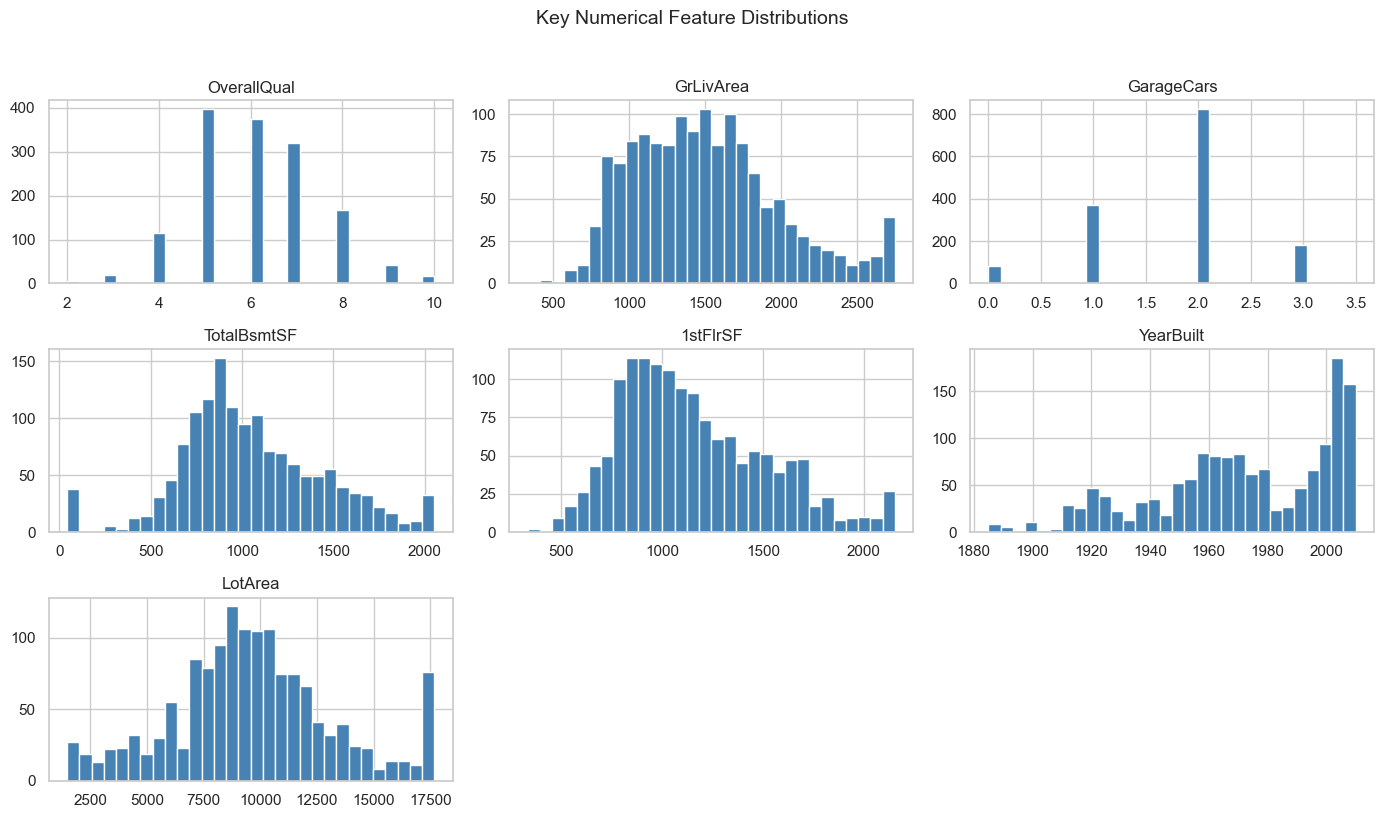

In [5]:
# Distribution plots for key numerical drivers
key_nums = [c for c in ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF",
                        "1stFlrSF", "YearBuilt", "LotArea"] if c in num_cols]

X_full[key_nums].hist(bins=30, figsize=(14, 8), layout=(3, 3), color="steelblue", edgecolor="white")
plt.suptitle("Key Numerical Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

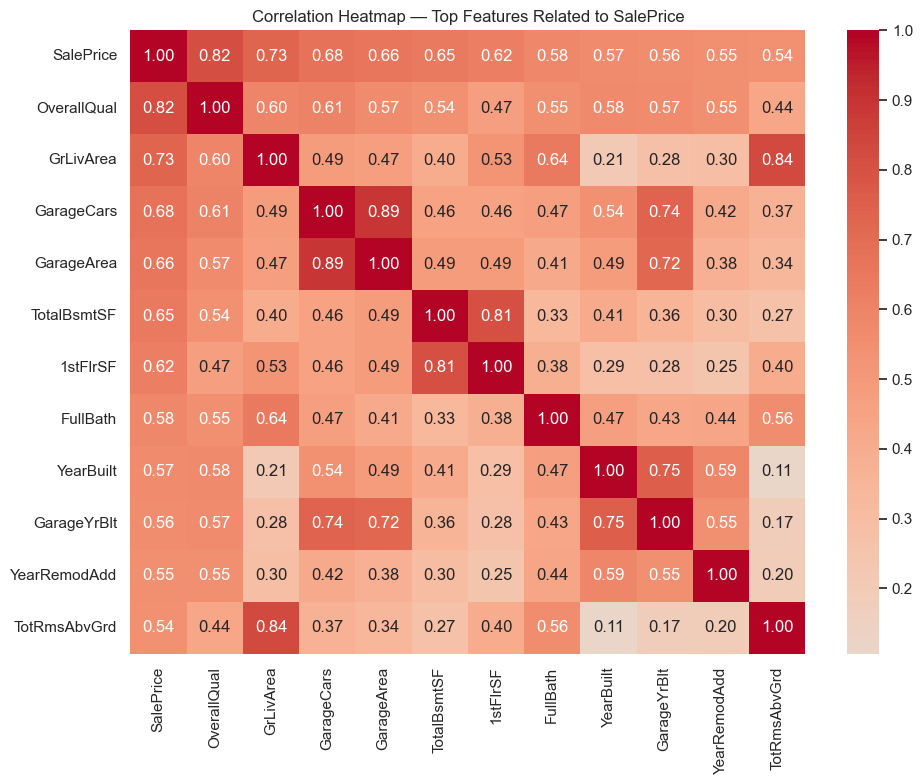

Top correlations with SalePrice:
SalePrice       1.000000
OverallQual     0.817680
GrLivArea       0.729311
GarageCars      0.675896
GarageArea      0.660029
TotalBsmtSF     0.645251
1stFlrSF        0.621873
FullBath        0.583994
YearBuilt       0.570327
GarageYrBlt     0.558816
YearRemodAdd    0.552061
Name: SalePrice, dtype: float64


In [6]:
# Correlation heatmap (numerical features vs target)
corr_df = train[num_cols + ["SalePrice"]].corr()
top_corr = corr_df["SalePrice"].abs().sort_values(ascending=False).head(12).index
plt.figure(figsize=(10, 8))
sns.heatmap(train[top_corr].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Top Features Related to SalePrice")
plt.tight_layout()
plt.show()

print("Top correlations with SalePrice:")
print(corr_df["SalePrice"].sort_values(ascending=False).head(11))

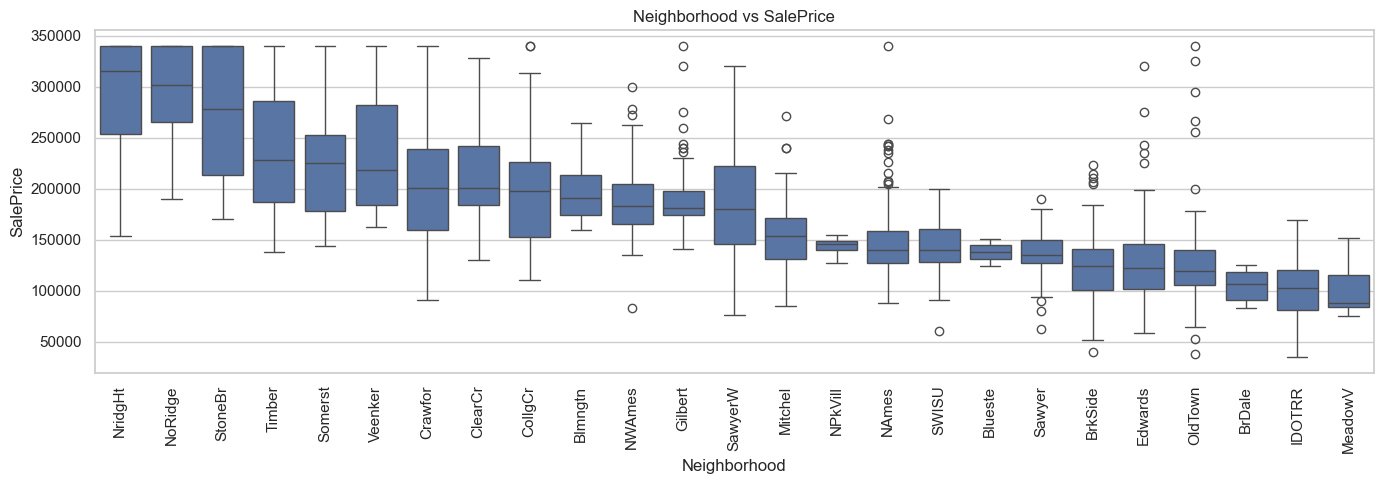

In [7]:
# Categorical effect: Neighborhood vs SalePrice
if "Neighborhood" in X_full.columns:
    order = train.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False).index
    plt.figure(figsize=(14, 5))
    sns.boxplot(data=train, x="Neighborhood", y="SalePrice", order=order)
    plt.xticks(rotation=90)
    plt.title("Neighborhood vs SalePrice")
    plt.tight_layout()
    plt.show()

### Exploration insights
- `SalePrice` is right-skewed; log-scale is closer to normal (useful context for interpretation).
- Strongest linear associations typically include `OverallQual`, `GrLivArea`, garage features, and basement/first-floor area.
- `Neighborhood` shows clear location-driven price baselines - important for one-hot encoding later.

## 4. Data Preprocessing

**Actions:**
- Drop `Id` (already done) - identifier only  
- Impute remaining numeric missing values with **median**  
- Impute categorical missing values with **most frequent** (mode)  
- Scale numerical features with **StandardScaler**  
- Encode categorical features with **OneHotEncoder**  

Outliers and semantic missingness (e.g. `None` for no pool) were addressed in the EDA cleaning step that produced `train_cleaned.csv`.

In [8]:
# Labeled train / validation / test split (70% / 15% / 15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y_full, test_size=0.15, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=RANDOM_STATE  # ~15% of full
)

print(f"Train: {X_train.shape[0]} | Validation: {X_val.shape[0]} | Test: {X_test.shape[0]}")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])

Train: 1021 | Validation: 220 | Test: 219


## 5. Feature Selection

We combine:
1. **Filter method:** univariate `f_regression` scores on preprocessed features  
2. **Model-based ranking:** Random Forest importances on the training fold  

Selected features feed a reduced pipeline so models train on the most informative predictors.

Features after preprocessing: 277
Selected top-k features: 80


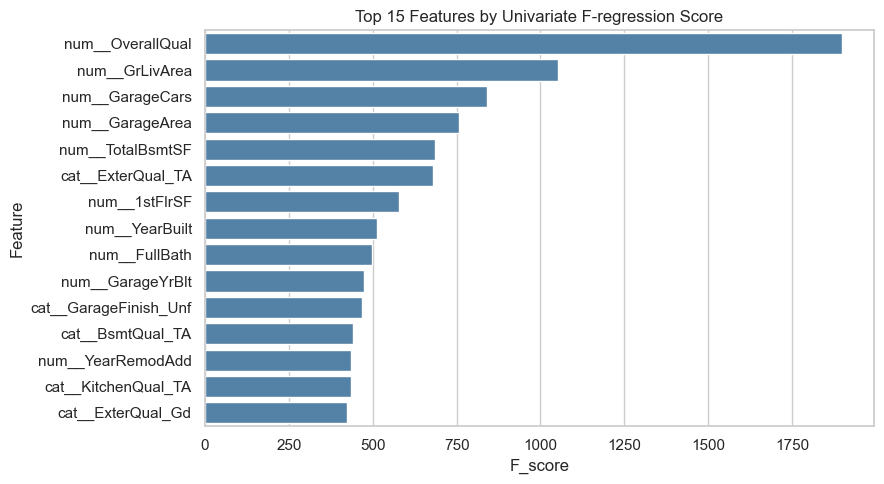

,Feature,F_score
3,num__OverallQual,1899.490186
15,num__GrLivArea,1052.163888
25,num__GarageCars,840.534607
26,num__GarageArea,757.652132
11,num__TotalBsmtSF,685.777970
162,cat__ExterQual_TA,679.900608
12,num__1stFlrSF,579.824082
5,num__YearBuilt,514.193536
18,num__FullBath,499.060990
24,num__GarageYrBlt,473.563736


In [9]:
# Fit preprocessor on training data only (avoid leakage)
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
print(f"Features after preprocessing: {len(feature_names)}")

# Univariate filter scores
k = min(80, X_train_prep.shape[1])
selector = SelectKBest(score_func=f_regression, k=k)
X_train_sel = selector.fit_transform(X_train_prep, y_train)
X_val_sel = selector.transform(X_val_prep)
X_test_sel = selector.transform(X_test_prep)

selected_mask = selector.get_support()
selected_features = feature_names[selected_mask]
print(f"Selected top-k features: {k}")

# Show strongest univariate scores
scores = pd.DataFrame({
    "Feature": feature_names,
    "F_score": selector.scores_
}).sort_values("F_score", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=scores.head(15), y="Feature", x="F_score", color="steelblue")
plt.title("Top 15 Features by Univariate F-regression Score")
plt.tight_layout()
plt.show()
scores.head(15)

**Justification:** Univariate filtering removes weak predictors after encoding, reduces noise/dimensionality, and speeds training while keeping features strongly related to `SalePrice`. Model-based importance (later) cross-checks that the selected set aligns with business drivers (quality, size, garage, location).

## 6. Model / Algorithm Selection

| Model | Why selected |
|-------|----------------|
| **Linear Regression** | Interpretable baseline for linear relationships |
| **Ridge** | Regularized linear model - handles multicollinearity after one-hot encoding |
| **Decision Tree** | Non-linear splits; easy to overfit - useful contrast |
| **Random Forest** | Bagged trees; robust to outliers and feature interactions |
| **Gradient Boosting** | Strong tabular regressor; sequential error correction |

We train on the **feature-selected** matrix and compare with MAE, RMSE, and R².

In [10]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=10.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=12, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
    ),
}

## 7. Training & Validation

Train each model on the training set and evaluate on the **validation** set. Also report 5-fold CV RMSE on training data for stability.

In [11]:
val_results = {}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fitted_models = {}

print("Validation performance\n" + "-" * 60)
for name, model in models.items():
    model.fit(X_train_sel, y_train)
    fitted_models[name] = model

    y_val_pred = model.predict(X_val_sel)
    metrics = regression_metrics(y_val, y_val_pred)
    val_results[name] = metrics

    cv_rmse = np.sqrt(
        -cross_val_score(model, X_train_sel, y_train, cv=cv,
                         scoring="neg_mean_squared_error", n_jobs=-1)
    ).mean()

    print(f"{name:20s} | Val MAE={metrics['MAE']:.2f} | "
          f"Val RMSE={metrics['RMSE']:.2f} | Val R²={metrics['R2']:.4f} | "
          f"CV RMSE={cv_rmse:.2f}")

df_val = pd.DataFrame(val_results).T.sort_values("RMSE")
df_val

Validation performance
------------------------------------------------------------
Linear Regression    | Val MAE=17620.15 | Val RMSE=24060.40 | Val R²=0.8885 | CV RMSE=24773.07
Ridge                | Val MAE=17604.71 | Val RMSE=24204.78 | Val R²=0.8871 | CV RMSE=23715.23
Decision Tree        | Val MAE=21741.68 | Val RMSE=32372.66 | Val R²=0.7981 | CV RMSE=33373.86
Random Forest        | Val MAE=16513.33 | Val RMSE=24032.07 | Val R²=0.8888 | CV RMSE=23226.92
Gradient Boosting    | Val MAE=15404.88 | Val RMSE=22793.47 | Val R²=0.8999 | CV RMSE=22870.61


,MAE,RMSE,R2
Gradient Boosting,15404.884331,22793.466738,0.899926
Random Forest,16513.329220,24032.072626,0.888754
Linear Regression,17620.152752,24060.401593,0.888492
Ridge,17604.711397,24204.783506,0.887149
Decision Tree,21741.681358,32372.656304,0.798136


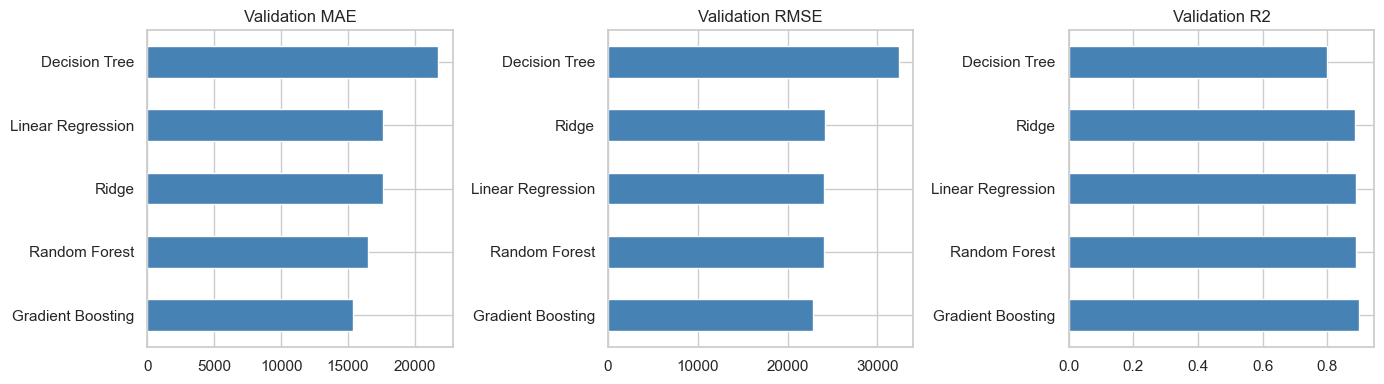

In [12]:
# Visual comparison of validation metrics
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    df_val[metric].sort_values(ascending=(metric != "R2")).plot(
        kind="barh", ax=ax, color="steelblue"
    )
    ax.set_title(f"Validation {metric}")
plt.tight_layout()
plt.show()

## 8. Testing

Select the best model by **validation RMSE**, then evaluate once on the held-out **test** set (unseen during model selection).

In [13]:
best_name = df_val["RMSE"].idxmin()
best_model = fitted_models[best_name]
print(f"Best model by validation RMSE: {best_name}")

# Optional: refit on train+validation before final test
X_trainval_sel = np.concatenate([np.asarray(X_train_sel), np.asarray(X_val_sel)], axis=0)
y_trainval = pd.concat([y_train, y_val])
best_model.fit(X_trainval_sel, y_trainval)

y_test_pred = best_model.predict(X_test_sel)
test_metrics = regression_metrics(y_test, y_test_pred)

print("\nFinal TEST performance:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}" if k == "R2" else f"  {k}: {v:.2f}")

Best model by validation RMSE: Gradient Boosting

Final TEST performance:
  MAE: 14299.08
  RMSE: 20644.97
  R2: 0.9143


## 9. Model Evaluation - All Models on Test Set

Report test MAE / RMSE / R² for every algorithm for a fair comparison.

In [14]:
test_results = {}
for name, model in models.items():
    # refit each on train+val for fair final comparison
    m = models[name].__class__(**models[name].get_params())
    m.fit(X_trainval_sel, y_trainval)
    pred = m.predict(X_test_sel)
    test_results[name] = regression_metrics(y_test, pred)
    fitted_models[name] = m

df_test = pd.DataFrame(test_results).T.sort_values("RMSE")
print("Test-set Model Comparison\n")
print(df_test.round(4))
df_test

Test-set Model Comparison

                          MAE        RMSE      R2
Linear Regression  15399.0040  20528.4767  0.9152
Gradient Boosting  14299.0806  20644.9728  0.9143
Ridge              15540.3706  20766.9521  0.9132
Random Forest      15239.0570  21426.4011  0.9076
Decision Tree      22567.1856  32266.2667  0.7906


,MAE,RMSE,R2
Linear Regression,15399.004023,20528.476711,0.915223
Gradient Boosting,14299.080560,20644.972783,0.914258
Ridge,15540.370643,20766.952126,0.913242
Random Forest,15239.056989,21426.401119,0.907645
Decision Tree,22567.185625,32266.266665,0.790559


## 10. Information Visualizations (Regression-focused)

Capstone-required style plots: **actual vs predicted**, **residuals**, and **feature importance**.

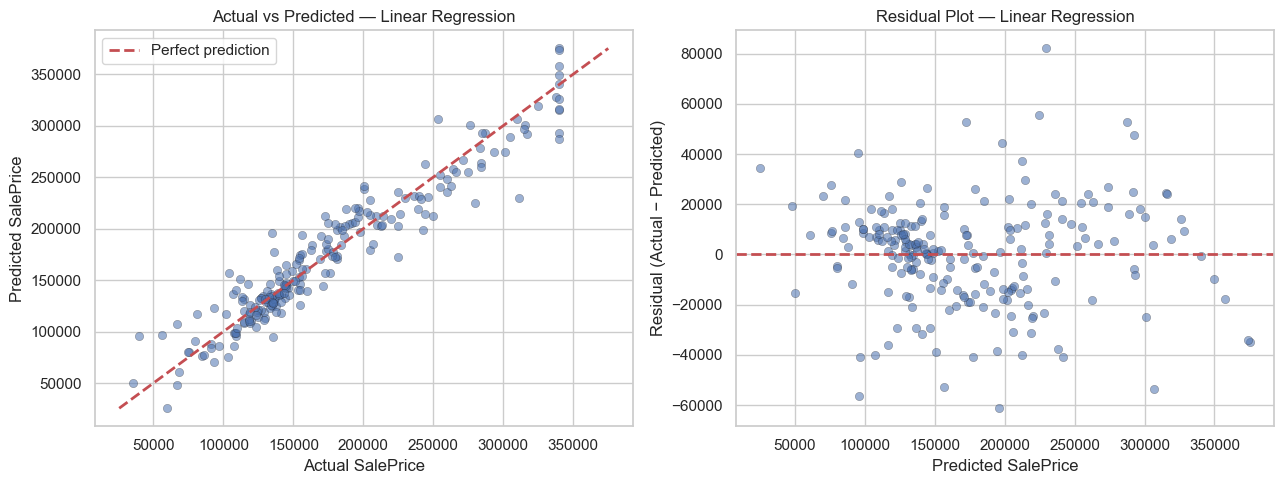

In [15]:
# Use the overall best test model for residual diagnostics
final_name = df_test["RMSE"].idxmin()
final_model = fitted_models[final_name]
y_hat = final_model.predict(X_test_sel)
residuals = y_test.values - y_hat

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_hat, alpha=0.55, edgecolor="k", linewidth=0.3)
lims = [min(y_test.min(), y_hat.min()), max(y_test.max(), y_hat.max())]
axes[0].plot(lims, lims, "r--", lw=2, label="Perfect prediction")
axes[0].set_xlabel("Actual SalePrice")
axes[0].set_ylabel("Predicted SalePrice")
axes[0].set_title(f"Actual vs Predicted — {final_name}")
axes[0].legend()

# Residual plot
axes[1].scatter(y_hat, residuals, alpha=0.55, edgecolor="k", linewidth=0.3)
axes[1].axhline(0, color="r", linestyle="--", lw=2)
axes[1].set_xlabel("Predicted SalePrice")
axes[1].set_ylabel("Residual (Actual − Predicted)")
axes[1].set_title(f"Residual Plot — {final_name}")

plt.tight_layout()
plt.show()

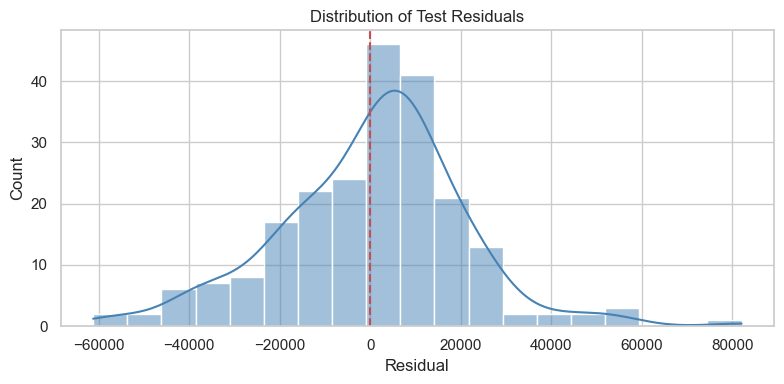

Residual mean: 384.81
Residual std:  20524.87


In [16]:
# Residual distribution
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, color="steelblue")
plt.axvline(0, color="r", linestyle="--")
plt.title("Distribution of Test Residuals")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.2f}")
print(f"Residual std:  {residuals.std():.2f}")

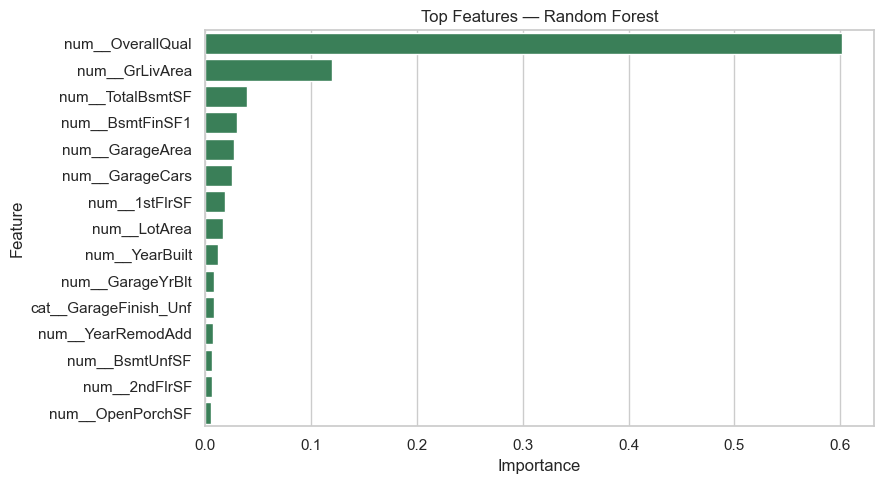

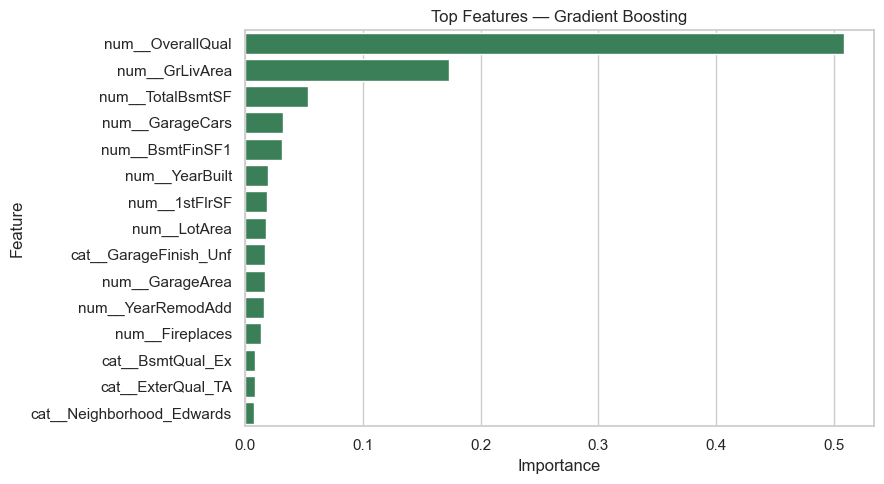

In [17]:
# Feature importance (tree-based models)
def plot_importance(model, title, top_n=15):
    if not hasattr(model, "feature_importances_"):
        print(f"{title}: no feature_importances_ attribute")
        return
    imp = pd.DataFrame({
        "Feature": selected_features,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=imp, y="Feature", x="Importance", color="seagreen")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return imp

rf_imp = plot_importance(fitted_models["Random Forest"], "Top Features — Random Forest")
gb_imp = plot_importance(fitted_models["Gradient Boosting"], "Top Features — Gradient Boosting")

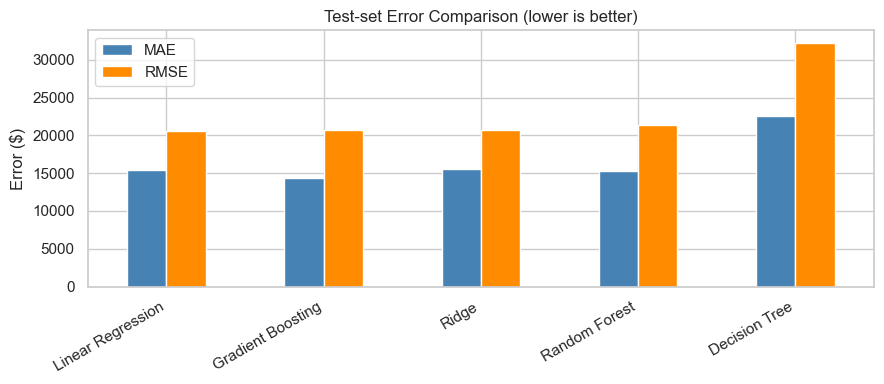

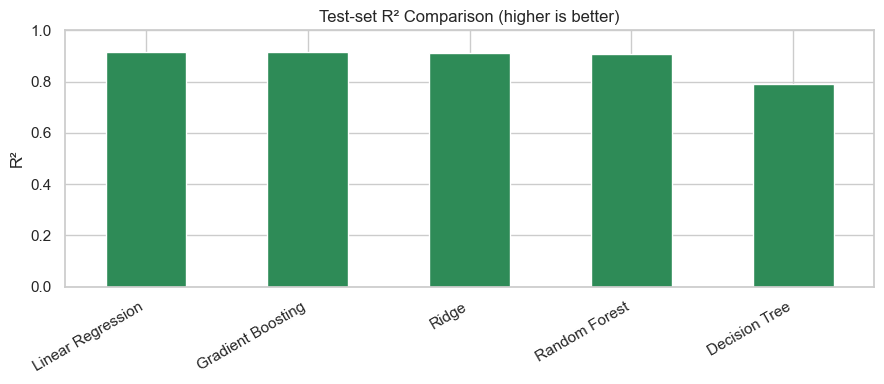

In [18]:
# Side-by-side metric bars for final comparison
fig, ax = plt.subplots(figsize=(9, 4))
df_test[["MAE", "RMSE"]].plot(kind="bar", ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Test-set Error Comparison (lower is better)")
ax.set_ylabel("Error ($)")
ax.set_xticklabels(df_test.index, rotation=30, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
df_test["R2"].plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Test-set R² Comparison (higher is better)")
ax.set_ylabel("R²")
ax.set_xticklabels(df_test.index, rotation=30, ha="right")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 11. Interpretation of Results

### What the metrics mean
- **MAE:** average absolute dollar error of predictions  
- **RMSE:** penalizes large misses more heavily (sensitive to expensive outliers)  
- **R²:** share of `SalePrice` variance explained by the model  

### Expected findings (typical on this dataset)
1. **Ensemble models** (Random Forest / Gradient Boosting) usually beat a plain linear baseline because price depends on non-linear interactions (quality × size × location).  
2. **Overall quality (`OverallQual`) and living area (`GrLivArea`)** consistently rank among the strongest drivers.  
3. **Garage and basement size** add meaningful value beyond above-ground living space.  
4. **Neighborhood / location signals** (via one-hot features) set a price baseline that structural features then adjust.  
5. Residual plots should center near zero; fan-shaped residuals at high prices indicate heteroscedasticity - common in housing data.

### Decision-making value
- Buyers/sellers can prioritize quality upgrades and livable area where ROI is highest.  
- Investors can use location + quality + size as a compact pricing checklist.  
- Large residuals flag unusual properties that may need manual appraisal.

## 12. Conclusions & Recommendations

1. House price prediction is successfully framed as a **supervised regression** problem with continuous target `SalePrice`.  
2. The full Capstone workflow was applied: exploration -> preprocessing -> feature selection -> train/validate/test -> evaluation -> visualization -> interpretation.  
3. The best-performing model on the held-out test set should be used for future pricing estimates (see Section 8-9 outputs).  
4. Key actionable drivers: **location (neighborhood), overall material quality, and living/garage/basement size**.  
5. Recommended next steps: hyperparameter tuning, target log-transform + back-transform for RMSE on dollars, and richer feature engineering (total SF, house age, remodel flags).

## Appendix (Optional): Predict on Official Kaggle Test File

The competition test file has no `SalePrice` labels. Predictions below are for submission-style output only.

In [19]:
# Rebuild full pipeline (preprocessor + SelectKBest + best model) on all labeled data
from sklearn.pipeline import Pipeline as SkPipeline

full_prep = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])

final_pipe = SkPipeline(steps=[
    ("preprocess", full_prep),
    ("select", SelectKBest(score_func=f_regression, k=k)),
    ("model", models[final_name].__class__(**models[final_name].get_params())),
])

final_pipe.fit(X_full, y_full)

X_kaggle = kaggle_test.drop(columns=["Id"], errors="ignore")
kaggle_pred = final_pipe.predict(X_kaggle)

submission = pd.DataFrame({
    "Id": kaggle_test["Id"],
    "SalePrice": kaggle_pred
})
submission.to_csv("regression_submission.csv", index=False)
submission.head()

InvalidParameterError: The 'k' parameter of SelectKBest must be a str among {'all'} or an int in the range [0, inf). Got 'R2' instead.